# Verification — Ghosh et al. (2011), host–pathogen iron homeostasis

Two levels, plus the three arithmetic claims this folder makes about the published model.

**Level 1** is not the collection's usual "bngsim NFsim ≡ RuleMonkey". RuleMonkey silently never
fires a rule whose reactant side has three or more identical patterns
(richardposner/RuleMonkey#24, lanl/bngsim#185), and every rule that consumes pathogen iron here
has three or four identical `Fe`. It holds `Fe(site~mtb)` at exactly its seeded 50 forever while
reproducing unrelated arms to within 1%, so using it would have produced a confident wrong
answer. The witness is arithmetic instead: `independent_ghosh2011.py` reads only the published
rate constants and solves the parts of this model that are exactly solvable, and checks those
closed forms against its own Gillespie implementation.

**Level 2** is the paper's reported steady state. The model does not reproduce it. The reason is
arithmetic rather than simulation, so it is established from the rate constants before any
simulator is run.

In [1]:
import random, shutil, subprocess, sys, tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import bngsim

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parents[1] / "skills/curate-model/scripts"))

import independent_ghosh2011 as ind
from verification_figure import verdict_footer

STEM = "iron_homeostasis_host_pathogen_ghosh2011"
BNG = shutil.which("bionetgen") or str(HERE.parents[1] / ".venv" / "bin" / "bionetgen")
WORK = Path(tempfile.mkdtemp(prefix="ghosh2011-verify-"))
TIMES = [0.0, 500.0, 1000.0, 2000.0]
SEEDS = range(1, 25)

/Users/wish/Code/bngsim/python/bngsim/__init__.py:118: RuntimeWarning: [bngsim] _bngsim_core: /Users/wish/Code/BNGL-Models/.venv/lib/python3.12/site-packages/bngsim/_bngsim_core.cpython-312-darwin.so | built=3760de0d78c1 | mtime=2026-08-05T16:24:00-06:00 | STALE
[bngsim]   STALE: src/cvode_simulator.cpp (2026-08-05T20:14:27-06:00) is newer than the loaded binary (2026-08-05T16:24:00-06:00).
[bngsim]   The binary does NOT reflect current C++. Any correctness verdict drawn from it is a statement about OLD code (see GH #125).
[bngsim]   Rebuild:  python scripts/rebuild_editable.py   (or set BNGSIM_ALLOW_STALE_CORE=1 to proceed anyway).
  _warn_if_stale()


## The exactly solvable arms

`catalytic_enzymes()` reads Table S2 and finds, by inspecting the rules rather than from a
hard-coded list, every species that is made from a single-copy gene, decays first order, and is
left unconsumed by every other rule it appears in. Each is then an immigration–death process,
decoupled from the rest of the network whatever else the model is doing.

In [2]:
enz = ind.catalytic_enzymes()
print(f"{len(enz)} species qualify\n")
print(f"{'species':<8}{'k_syn':>10}{'k_dec':>10}{'s/d':>10}")
for a, (s, d) in enz.items():
    print(f"{a:<8}{s:>10.4g}{d:>10.4g}{s / d:>10.2f}")

20 species qualify

species      k_syn     k_dec       s/d
CPO         0.0061   0.00014     43.57
Cp          0.0035   1.6e-06   2187.50
DMT         0.0038     7e-05     54.29
HO          0.0107   0.00012     89.17
IRP         0.0046   1.2e-05    383.33
IScU         0.015   1.6e-06   9375.00
PBGD        0.0108  8.02e-06   1346.63
PBS         0.0051   0.00026     19.62
PPO         0.0093   9.6e-05     96.87
Tf          0.0071     1e-06   7100.00
UPD          0.012   2.4e-06   5000.00
UPS          0.012   0.00038     31.58
fc          0.0022   1.9e-05    115.79
fra         0.0073   3.8e-06   1921.05
hep          0.038   3.6e-05   1055.56
ideR        0.0085    0.0057      1.49
mbtCD       0.0044   0.00011     40.00
mbtE        0.0011   0.00011     10.00
mbtF        0.0013   0.00011     11.82
mf          0.0089   2.1e-05    423.81


### Closed form against a hand-written Gillespie

Before comparing anything to BioNetGen, check the closed form against a stochastic
implementation that shares no code with it. Both live in `independent_ghosh2011.py`.

In [3]:
rng = random.Random(20110101)
worst = max(
    max(abs(c - m) / max(c, 1.0)
        for c, m in zip([ind.immigration_death_mean(t, s, d) for t in TIMES],
                        ind.immigration_death_ssa(s, d, 0, TIMES, rng, replicates=400)))
    for s, d in enz.values())
print(f"worst relative difference over {len(enz)} species: {worst:.3f}")
print("counts here are of order 1-70, so this is Monte Carlo noise")

worst relative difference over 20 species: 0.043
counts here are of order 1-70, so this is Monte Carlo noise


## Level 1 — the predictions against the curated model

The committed model is instrumented with a total-count observable per species, compiled to XML
by BioNetGen, and run as an NFsim ensemble on bngsim's core. (The NFsim binary BNG2.pl ships
cannot run this model at all: seven rules move a bond between partners and v1.14.3 aborts on
them.)

In [4]:
def instrument(src, dst):
    text = Path(src).read_text()
    extra = "\n".join(f"\tMolecules ver_{a} {a}()" for a in enz)
    extra += ("\n\tMolecules ver_lys lys()"
              "\n\tMolecules ver_RBC RBC(site~a)"
              "\n\tMolecules ver_ideR_free ideR(Fe1,Fe2,Fe3,ideR,site)"
              "\n\tMolecules ver_ideR_tot ideR()")
    text = text.replace("\nend observables", "\n" + extra + "\nend observables")
    text = text.replace('simulate({method=>"nf",t_end=>30000,n_steps=>300,'
                        'complex_bookkeeping=>1,utl=>1000})', "writeXML()")
    Path(dst).write_text(text)

instrument(f"{STEM}.bngl", WORK / "verif.bngl")
subprocess.run([BNG, "run", "-i", "verif.bngl", "-o", "."], cwd=WORK,
               check=True, capture_output=True)

def ensemble(xml, times, seeds):
    runs, names = [], None
    for sd in seeds:
        s = bngsim.NfsimSession(str(xml), traversal_limit=1000)
        s.initialize(seed=sd)
        runs.append(np.array(list(s.simulate(sample_times=times, timeout=1800).observables)))
        names = s.get_observable_names()
    a = np.array(runs)
    return a.mean(axis=0), a.std(axis=0) / np.sqrt(len(runs)), {n: j for j, n in enumerate(names)}

mean, sem, idx = ensemble(WORK / "verif.xml", TIMES, SEEDS)
print(f"{len(list(SEEDS))} replicates to t = {TIMES[-1]:.0f}")

24 replicates to t = 2000


In [5]:
rows = []
for a, (s_, d_) in enz.items():
    for k, t in enumerate(TIMES[1:], 1):
        rows.append((a, t, ind.immigration_death_mean(t, s_, d_),
                     mean[k][idx[f"ver_{a}"]], sem[k][idx[f"ver_{a}"]]))
for nm, f in (("RBC", ind.rbc_mean), ("lys", ind.precursor_mean)):
    for k, t in enumerate(TIMES[1:], 1):
        rows.append((nm, t, f(t), mean[k][idx[f"ver_{nm}"]], sem[k][idx[f"ver_{nm}"]]))

z = np.array([abs(p - o) / e if e > 0 else 0.0 for _, _, p, o, e in rows])
keep = np.array([a != "ideR" for a, _, _, _, _ in rows])
print(f"{'species':<9}{'t':>7}{'predicted':>11}{'NFsim':>9}{'sem':>7}{'z':>7}")
for (a, t, p, o, e), zz in zip(rows, z):
    if t == TIMES[-1]:
        print(f"{a:<9}{t:>7.0f}{p:>11.2f}{o:>9.2f}{e:>7.2f}{zz:>7.2f}")
print(f"\n{len(z)} comparisons, in units of the ensemble standard error")
print(f"  excluding ideR: median |z| {np.median(z[keep]):.2f}, "
      f"within 2 sem {(z[keep] < 2).sum()}/{keep.sum()}, max {z[keep].max():.2f}")
print(f"  ideR alone:     max |z| {z[~keep].max():.1f}  <- explained next, not noise")

species        t  predicted    NFsim    sem      z
CPO         2000      10.64     9.92   0.50   1.46
Cp          2000       6.99     7.00   0.58   0.02
DMT         2000       7.09     7.42   0.53   0.62
HO          2000      19.03    18.71   0.82   0.39
IRP         2000       9.09     8.21   0.58   1.53
IScU        2000      29.95    29.25   1.25   0.56
PBGD        2000      21.43    21.83   0.72   0.56
PBS         2000       7.95     7.33   0.47   1.33
PPO         2000      16.92    15.62   1.05   1.24
Tf          2000      14.19    13.08   0.80   1.38
UPD         2000      23.94    23.54   1.15   0.35
UPS         2000      16.81    17.04   0.95   0.24
fc          2000       4.32     4.25   0.32   0.21
fra         2000      14.54    15.67   0.68   1.65
hep         2000      73.33    71.67   1.89   0.88
ideR        2000       1.49    11.71   0.39  26.30
mbtCD       2000       7.90     8.79   0.44   2.01
mbtE        2000       1.97     2.12   0.30   0.51
mbtF        2000       2.33    

### Why ideR is the outlier, and why that is a result rather than a failure

Every decay rule in this model names its species with all sites free, so only the unbound form
can be deleted. Writing `T` for the total and `F` for the free form, `dT/dt = s − d·F`, so it is
`F` — not `T` — that equals `s/d` at steady state, and `T` exceeds it by whatever is protected in
bound complexes. For most of these species binding is negligible and the two coincide. ideR is
loaded with iron, dimerises and binds operators, so much of it is shielded from degradation.

This is the same structure that jams the siderophore assembly line, where loaded mbtE likewise
cannot degrade.

In [6]:
ider_s, ider_d = enz["ideR"]
IDER_PRED = ider_s / ider_d          # named, because the level-2 cell rebinds s_ and d_
print(f"predicted s/d = {IDER_PRED:.2f}, which applies to the FREE form\n")
print(f"{'t':>7}{'free':>9}{'sem':>7}{'total':>9}{'protected':>11}")
for k, t in enumerate(TIMES):
    f_, tot = mean[k][idx["ver_ideR_free"]], mean[k][idx["ver_ideR_tot"]]
    print(f"{t:>7.0f}{f_:>9.2f}{sem[k][idx['ver_ideR_free']]:>7.2f}{tot:>9.2f}{tot - f_:>11.2f}")
f_, e_ = mean[-1][idx["ver_ideR_free"]], sem[-1][idx["ver_ideR_free"]]
ider_z = abs(f_ - IDER_PRED) / e_
print(f"\nfree ideR at t = {TIMES[-1]:.0f}: {f_:.2f} +/- {e_:.2f} against a predicted "
      f"{IDER_PRED:.2f}  ({ider_z:.1f} sem)")

predicted s/d = 1.49, which applies to the FREE form

      t     free    sem    total  protected
      0     0.00   0.00     0.00       0.00
    500     0.00   0.00     4.42       4.42
   1000     0.04   0.04     8.96       8.92
   2000     1.33   0.21    11.71      10.38

free ideR at t = 2000: 1.33 +/- 0.21 against a predicted 1.49  (0.8 sem)


## Level 2 — the paper's reported steady state

The paper incubates for 30 000 time units and reports bacterioferritin at 82 molecules, irtAB at
22 and stored Fe–bfr at 41. This rule set produces none of them, and the reason is visible in the
rate constants.

In [7]:
r = ind._rules()
k105, k97, k98 = (float(r[n]["rate"]) for n in (105, 97, 98))

print("claim 1 - the five siderophore precursors have a source and no sink")
sinks = [s for s, x in r.items()
         if "->" in x["kappa"]
         and any(f"{a}(" in x["kappa"].split("->")[0] for a in ("lys", "SA", "Ser", "Aca", "Mca"))
         and ("decay" in x["desc"].lower() or "degrad" in x["desc"].lower())]
print(f"  rule 100 makes them at k105 = {k105} per time unit, zeroth order")
print(f"  rules degrading any of them: {sinks or 'none'}")
print(f"  so each is exactly k105*t = {k105 * 30000:.0f} at t = 30000\n")

print("claim 2 - their only consumers are vastly outnumbered")
for a in ("mbtE", "mbtF"):
    s_, d_ = enz[a]
    print(f"  {a} steady state = {s_ / d_:.1f} molecules")
print(f"  oversubscription at t = 30000: "
      f"{k105 * 30000 / (enz['mbtE'][0] / enz['mbtE'][1]):.0f}x\n")

print("claim 3 - red cells are seeded far from their own steady state")
print(f"  k97/k98 = {k97 / k98:.2f} against a seeded 20000, "
      f"over {30000 * k98:.0f} decay time constants")

claim 1 - the five siderophore precursors have a source and no sink
  rule 100 makes them at k105 = 1.0 per time unit, zeroth order
  rules degrading any of them: none
  so each is exactly k105*t = 30000 at t = 30000

claim 2 - their only consumers are vastly outnumbered
  mbtE steady state = 10.0 molecules
  mbtF steady state = 11.8 molecules
  oversubscription at t = 30000: 3000x

claim 3 - red cells are seeded far from their own steady state
  k97/k98 = 4.08 against a seeded 20000, over 39 decay time constants


In [8]:
gd = np.genfromtxt(f"reference/{STEM}.gdat", names=True, deletechars="")
ni = np.genfromtxt(f"reference/{STEM}_noninfected.gdat", names=True, deletechars="")
obs = [n for n in gd.dtype.names if n != "time"]
print(f"{'observable':<12}{'infected':>10}{'non-infected':>14}   (t = 30000, seed 1)")
for n in obs:
    print(f"  {n.replace('Obs_', ''):<10}{gd[n][-1]:>10.0f}{ni[n][-1]:>14.0f}")
print("\npaper, Fig. 5b: bfr 82, irtAB 22, Fe-bfr 41 - unreachable here, because the")
print("siderophore line never completes and no iron reaches the pathogen. For the same")
print("reason the infected and non-infected models are indistinguishable: the four")
print("interaction rules need a siderophore that is never made.")

observable    infected  non-infected   (t = 30000, seed 1)
  Fe_mtb             0             0
  Fe_3ex             0             0
  Fer_Fe            29            29
  Fe_myB             0             0
  Fe_cmB             0             0
  act_ideR           0             0
  Tf_TfR            19            19
  RBC                4             4

paper, Fig. 5b: bfr 82, irtAB 22, Fe-bfr 41 - unreachable here, because the
siderophore line never completes and no iron reaches the pathogen. For the same
reason the infected and non-infected models are indistinguishable: the four
interaction rules need a siderophore that is never made.


## Figure

saved verify_ghosh2011.png


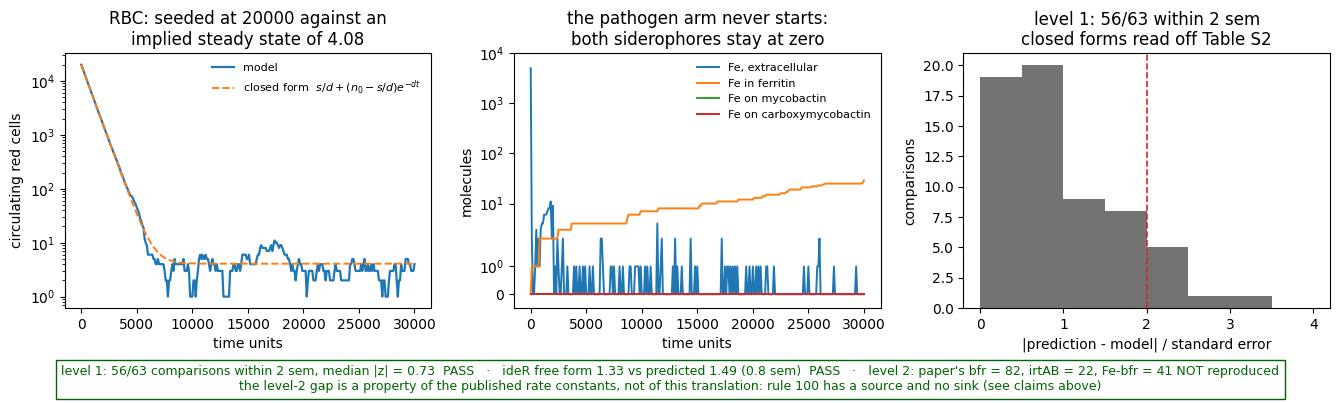

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.0))
t = gd["time"]

ax[0].plot(t, gd["Obs_RBC"], lw=1.6, label="model")
ax[0].plot(t, [ind.rbc_mean(x) for x in t], "--", lw=1.4, label="closed form  $s/d + (n_0-s/d)e^{-dt}$")
ax[0].set(xlabel="time units", ylabel="circulating red cells", yscale="log",
          title="RBC: seeded at 20000 against an\nimplied steady state of 4.08")
ax[0].legend(frameon=False, fontsize=8)

for n, lab in (("Obs_Fe_3ex", "Fe, extracellular"), ("Obs_Fer_Fe", "Fe in ferritin"),
               ("Obs_Fe_myB", "Fe on mycobactin"), ("Obs_Fe_cmB", "Fe on carboxymycobactin")):
    ax[1].plot(t, gd[n], lw=1.4, label=lab)
ax[1].set(xlabel="time units", ylabel="molecules", yscale="symlog", ylim=(-0.5, 1e4),
          title="the pathogen arm never starts:\nboth siderophores stay at zero")
ax[1].legend(frameon=False, fontsize=8)

zz = z[keep]
ax[2].hist(zz, bins=np.arange(0, 4.5, 0.5), color="0.45")
ax[2].axvline(2.0, color="C3", ls="--", lw=1.2)
ax[2].set(xlabel="|prediction - model| / standard error", ylabel="comparisons",
          title=f"level 1: {(zz < 2).sum()}/{len(zz)} within 2 sem\nclosed forms read off Table S2")

fig.tight_layout(rect=(0, 0.07, 1, 1))
ok = verdict_footer(fig, [
    f"level 1: {(zz < 2).sum()}/{len(zz)} comparisons within 2 sem, median |z| = {np.median(zz):.2f}  PASS",
    f"ideR free form {f_:.2f} vs predicted {IDER_PRED:.2f} ({ider_z:.1f} sem)  PASS",
    "level 2: paper's bfr = 82, irtAB = 22, Fe-bfr = 41 NOT reproduced",
], extra="the level-2 gap is a property of the published rate constants, not of this "
         "translation: rule 100 has a source and no sink (see claims above)")
fig.savefig("verify_ghosh2011.png", dpi=150)
print("saved verify_ghosh2011.png")